# Soft Actor-Critic (SAC) Algorithm
## 1. Core Idea
### 1.1 Entropy Regularized Policy Optimization (*Policy Improvement*)
We use the average reward metic ($\bar{v}_\pi=\mathbb{E}_{S \sim d}\left[v_\pi(S)\right]$) to define the objective function of the policy optimization problem. The objective function is defined as the sum of the expected reward and the entropy of the policy. The entropy term is used to encourage exploration. The objective function is defined as follows:
\begin{equation}
J(\pi)=\sum_{t=0}^T \mathbb{E}_{\left(s_t, a_t\right) \sim \rho_\pi}\left[r\left(s_t, a_t\right)+\alpha \mathcal{H}\left(\pi\left(\cdot \mid s_t\right)\right)\right], \tag{1}
\end{equation}
where $\mathcal{H}\left(\pi\left(\cdot \mid s_t\right)\right)$ is the entropy of the policy $\pi$ at state $s_t$ and $\alpha$ is the entropy coefficient. The entropy term is defined as follows:
\begin{equation}
\mathcal{H}\left(\pi\left(\cdot \mid s_t\right)\right)= \mathbb{E}_{a_t \sim \pi\left(\cdot \mid s_t\right)}\left[-\log \pi\left(a_t \mid s_t\right)\right]. \tag{2}
\end{equation}


### 1.2 Soft Value Functions (*Policy Evaluation*)
Let the entropy reward involving the entropy term
\begin{equation}
r^{soft}\left(s_t, a_t\right) \triangleq r\left(s_t, a_t\right)+\mathbb{E}_{s_{t+1} \sim p}\left[\mathcal{H}\left(\pi\left(\cdot \mid s_{t+1}\right)\right)\right].
\end{equation}

Thus, the 'soft' $V$ and $Q$ functions are defined as follows:
\begin{equation}
Q\left(s_t, a_t\right) \triangleq \underset{(s_t, a_t) \sim p_\pi}{\mathbb{E}}\left[\sum_{t^{\prime}=t}^T \gamma^{t^{\prime}-t} ~ r\left(s_t, a_t\right)+\alpha \sum_{t^{\prime}=t+1}^T \gamma^{t^{\prime}-t} \mathcal{H}\left(\pi\left(\cdot \mid s_t\right)\right)\right], \tag{3}
\end{equation}

\begin{equation}
V\left(s_t\right) \triangleq \underset{(s_t, a_t) \sim \rho_\pi}{\mathbb{E}}\left[\sum_{t^{\prime}=t}^T \gamma^{t^{\prime}-t}\left(r\left(s_t, a_t\right)+\alpha \mathcal{H}\left(\pi\left(\cdot \mid s_t\right)\right)\right)\right]. \tag{4}
\end{equation}

Note that, in the soft Q function, the entropy term in time step $t$ is omitted since the action is decided. Comparing the two equations, we have

\begin{equation}
\begin{aligned}
V\left(s_t\right)&=\underset{a_t \sim \pi\left(\cdot \mid s_t\right)}{\mathbb{E}}\left[Q\left(s_t, a_t\right)+\alpha \mathcal{H}\left(\pi\left(\cdot \mid s_t\right)\right)\right]\\
&=\underset{a_t \sim \pi\left(\cdot \mid s_t\right)}{\mathbb{E}}\left[Q\left(s_t, a_t\right)-\alpha \log \pi\left(\cdot | s_t \right) \right].
\end{aligned} \tag{5}
\end{equation}

Additionally, by comparing $Q\left(s_t, a_t\right)$ and $V\left(s_{t+1}\right)$, we have
\begin{equation}
Q\left(s_t, a_t\right)=r\left(s_t, a_t\right)+ \gamma \cdot \underset{s_{t+1} \sim p\left(\cdot \mid s_t, a_t\right)} {\mathbb{E}}\left[V\left(s_{t+1}\right)\right]. \tag{6}
\end{equation}

## 2. Implementation
### 2.1 Forming Loss Functions
The above two equations are actually the actor loss (maximization) and critic loss in the soft actor-critic framework. Parameterized by $\theta$, the policy $\pi$ is optimized by maximizing the average reward metric. In addition, the Q function is parameterized by $\omega$ and is optimized by minimizing the Bellman error. The actor loss is defined as
\begin{equation}
\mathcal{L}_{\text {actor}}=-\underset{(s,a) \sim \mathcal{D}}{\mathbb{E}}\left[Q_{\omega}\left(s, a\right)-\alpha \log \pi_{\theta}\left( \cdot \mid s\right)\right], \tag{7}
\end{equation}
where $\mathcal{D}$ is any previous experience data.

To estimate the Q value and avoid estimating the value function, we devise a 'soft' Bellman equation of Q using (5) and (6) as
\begin{equation}
Q\left(s_t, a_t\right) = r\left(s_t, a_t\right) + \gamma \cdot \left(\underset{a_{t+1} \sim \pi\left(\cdot \mid s_{t+1}\right),~s_{t+1} \sim p\left(\cdot \mid s_t, a_t\right)}{\mathbb{E}}\left[Q\left(s_{t+1}, a_{t+1}\right)-\alpha \log \pi\left(\cdot \mid s_{t+1}\right)\right]\right). \tag{8}
\end{equation}
Thus, the critic loss is defined as
\begin{equation}
\mathcal{L}_{\text {critic}}= \operatorname{MSE}\left(Q_{\omega}\left(s, a\right), r\left(s, a\right) + \gamma \left(1-d\right) \cdot \left(Q_{\omega}\left(s^{\prime}, a^{\prime}\right)-\alpha \log \pi_{\theta}\left(a^{\prime} \mid s^{\prime}\right)\right)\right),~~ (s,a) \in \mathcal{D}, \tag{9}
\end{equation}
where $d$ is the 'done' flag.


### 2.2 Reparameterization Trick
The Gaussian policy is hard to be undifferentiated due to the sample operation ($\pi(\cdot|\cdot)$). To achieve a differentiable Gaussian policy, the policy network outputs the mean $\mu_\theta(s)$ and standard deviation $\sigma_\theta(s)$, then added a noise $\xi$ sampled from a standard normal Gaussian distribution. Finally, a tanh function is applied to the sum to get the action. The reparameterization trick is defined as
\begin{equation}
\tilde{a}_\theta(s, \xi)=\tanh \left(\mu_\theta(s)+\sigma_\theta(s) \odot \xi\right), \quad \xi \sim \mathcal{N}(0, I) .  \tag{10}
\end{equation}
Thus, the represented actor loss is
\begin{equation}
\mathcal{L}_{\text {actor}}=-\underset{s \sim \mathcal{D}, ~ \xi \sim \mathcal{N}}{\mathbb{E}}\left[Q_{\omega}\left(s, \tilde{a}_\theta(s, \xi)\right)-\alpha \log \pi_{\theta}\left(\tilde{a}_\theta(s, \xi) \mid s\right)\right]. \tag{11}
\end{equation}

### 2.3 Calculation of the Recast $\log \pi\left(\tilde{a} | s \right)$
Note that, the action is clipped by the tanh function, so the PDF of the action is not the Gaussian distribution. Let $\tilde{a} = \tanh(u)$ where $\tilde{a}$ and $u$ are $n$-dim vectors, we define the Jacobian matrix $J$ as
\begin{equation}
\begin{aligned}
J&=\frac{\mathrm{d} \tilde{a}}{\mathrm{d} u} \\
&=\operatorname{diag}\left(1-\tilde{a}_1^2, 1-\tilde{a}_2^2, \ldots, 1-\tilde{a}_n^2\right). \tag{12}
\end{aligned}
\end{equation}
Let $\mu \left(u|s\right)$ be the corresponding distribution of the action $\tilde{a}$. In a very samll neighborhood of $u$ (or $\tilde{a}$), we have
\begin{equation}
\begin{aligned}
&\pi\left(\tilde{a} | s \right) \left|\mathrm{d}\tilde{a} \right| = \mu \left(u|s\right) \left|\mathrm{d}u \right| \\
&\Rightarrow \pi\left(\tilde{a} | s \right) = \mu \left(u|s\right)  \left| \frac{\mathrm{d}u}{\mathrm{d}\tilde{a}} \right|  = \mu \left(u|s\right) \left|\frac{1}{\operatorname{det}(J)}\right|. \tag{13}
\end{aligned}
\end{equation}
Since the Jacobian matrix is diagonal, we have
\begin{equation}
|\operatorname{det}(J)|=\prod_{i=1}^n\left(1-\tilde{a}_i^2\right), \tag{14}
\end{equation}
and thus
\begin{equation}
\pi\left(\tilde{a} | s \right) = \mu \left(u|s\right) \left[ \prod_{i=1}^n\left(1-\tilde{a}_i^2\right) \right]^{-1}. \tag{15}
\end{equation}
We take both sides of the equation the logarithm, thus
\begin{equation}
\log \pi\left(\tilde{a} | s \right) = \log \mu \left(u|s\right) - \prod_{i=1}^n\log\left(1-\tilde{a}_i^2\right). \tag{16}
\end{equation}
Thus, 
\begin{equation}
\log \pi\left(\tilde{a} | s \right) = \log \mu \left(u|s\right) - \prod_{i=1}^n\log\left(1-tanh^2(u_i)\right). \tag{17}
\end{equation}

Note that, the term $\log\left(1-tanh^2(u_i)\right)$ can be replaced by a more stable calculation
\begin{equation}
\begin{aligned}
\log \left(1-\tanh ^2\left(u_i\right)\right)&=\log \left(\operatorname{sech}^2\left(u_i\right)\right)=2 \log \left(\operatorname{sech}\left(u_i\right)\right) \\
&=2 \log \left(\frac{2}{\exp \left(u_i\right)+\exp \left(-u_i\right)}\right)=2 \log (2)-\log \left(\exp \left(u_i\right)+\exp \left(-u_i\right)\right)\\
&=2 \log (2)-\log \left(\exp \left(u_i\right)+\exp \left(-u_i\right)\right)\\
&=2 \log (2)-\log \left(\exp \left(u_i\right)\right)-\log \left(1+\exp \left(-2 u_i\right)\right)\\
&=2 \log (2)-u_i-\operatorname{softplus}\left(-2 u_i\right), \tag{18}
\end{aligned}
\end{equation}
where $\operatorname{softplus}(x)=\log \left(1+\exp (x)\right)$.

### 2.4 Double-Q and Target Network Trick
The double-Q trick is used to stabilize the training of the Q function. In addition, the target network is involved to stabilize the training of the Q function. Similar to DDPG, there are actually four Q networks in the SAC algorithm: $Q_{\phi 1}$ and $Q_{\phi 2}$ for the current Q value and $Q_{\omega 1}$ and $Q_{\omega 2}$ for the target Q value. The target Q value is calculated by the minimum of the two networks. The $i^{th}$ critic loss is defined as
\begin{equation}
\mathcal{L}_{\text {critic}}(i)= \operatorname{MSE}\left(Q_{\phi_i}\left(s, \tilde{a}\right), r\left(s, \tilde{a}\right) + \gamma \left(1-d\right) \cdot \left(\min\left(Q_{\omega_1}\left(s^{\prime}, \tilde{a}^{\prime}\right), Q_{\omega_2}\left(s^{\prime}, \tilde{a}^{\prime}\right)\right)-\alpha \log \pi_{\theta}\left(\tilde{a}^{\prime} \mid s^{\prime}\right)\right)\right),~\text{for}~i=1,2. \tag{19}
\end{equation}
The minimal value of the two target Q networks is adopted to calculate the Q value in the actor loss:
\begin{equation}
\mathcal{L}_{\text {actor}}=-\underset{s \sim \mathcal{D}, ~ \xi \sim \mathcal{N}}{\mathbb{E}}\left[\min\left(Q_{\phi_1}\left(s, \tilde{a}(s, \xi)\right), Q_{\phi_2}\left(s, \tilde{a}(s, \xi)\right)\right)-\alpha \log \pi_{\theta}\left(\tilde{a}(s, \xi) \mid s\right)\right]. \tag{20}
\end{equation}

In [1]:
import numpy as np
import gymnasium as gym
import torch
import collections
import random
import copy
import torch.nn.functional as F
from typing import Tuple
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [2]:
class SAC_Agent():
    
    def __init__(self,
                 replay_buffer:collections.deque,
                 batch_size:int,
                 target_update_tau:float, # The parameter for soft update
                 actor_network:torch.nn, 
                 critic_network_1:torch.nn,
                 critic_network_2:torch.nn,
                 actor_optimizer:torch.optim,
                 critic_optimizer:torch.optim,
                 target_entropy:float,
                 gamma:float = 0.9,
                 alpha_lr:float = 1.0e-3,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.device = device        
        self.replay_buffer = replay_buffer
        self.batch_size = batch_size
        self.target_update_tau = target_update_tau
        self.critic_network_1 = critic_network_1
        self.target_critic_network_1 = copy.deepcopy(critic_network_1).to(self.device)
        self.critic_network_2 = critic_network_2
        self.target_critic_network_2 = copy.deepcopy(critic_network_2).to(self.device)
        self.actor_network = actor_network
        
        #NOTE: The target critic network should be only updated via polyak averaging
        for params in self.target_critic_network_1.parameters():
            params.requires_grad = False
        for params in self.target_critic_network_2.parameters():
            params.requires_grad = False
        
        self.critic_optimizer = critic_optimizer
        self.actor_optimizer = actor_optimizer
        self.gamma = gamma
        self.target_entropy = target_entropy
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha = self.log_alpha.exp().item()
        self.alpha_optimizer = torch.optim.Adam([self.log_alpha], lr=alpha_lr)
            
    def get_action(self,obs:torch.tensor) -> Tuple[torch.tensor,torch.tensor]:
        '''
        For policy evaluation
        '''
        # obtain mean and std of Gaussian distribution
        mu, std = self.actor_network(obs)
        # Reparameterization trick (mean + std * N(0,1))
        dist = torch.distributions.Normal(mu, std)
        sample = dist.rsample()
        action = torch.tanh(sample)
        log_pi = dist.log_prob(sample).sum(axis=-1) \
                    - (2*(np.log(2) - sample - F.softplus(-2*sample))).sum(axis=-1)
                            
        return action, log_pi.unsqueeze(-1)
    
    def get_behavior_action(self,obs:np.ndarray) -> np.array:
        '''
        For interaction with the environment
        '''
        obs = torch.tensor(obs,dtype=torch.float32).to(self.device)
        mu, std = self.actor_network(obs)
        dist = torch.distributions.Normal(mu, std)
        sample = dist.sample()
        action = torch.tanh(sample)
        return action.cpu().detach().numpy() 
        
    def batch_Q_approximation(self,
                              obs:torch.tensor,
                              action:torch.tensor,
                              reward:torch.tensor,
                              next_obs:torch.tensor,
                              done:torch.tensor) -> None:
        """To update the main critic network"""
        current_Q1 = self.critic_network_1(obs,action)
        current_Q2 = self.critic_network_2(obs,action)
        with torch.no_grad():
            next_action, next_log_pi = self.get_action(next_obs)
            target_Q1 = self.target_critic_network_1(next_obs,next_action)
            target_Q2 = self.target_critic_network_2(next_obs,next_action)
            TD_target = reward + self.gamma * (1-done) * (torch.min(target_Q1,target_Q2) - self.alpha * next_log_pi)
                    
        critic_loss_1 = F.mse_loss(current_Q1,TD_target)
        critic_loss_2 = F.mse_loss(current_Q2,TD_target)
        critic_loss = critic_loss_1 + critic_loss_2
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
    def batch_policy_optimization(
        self,
        obs:torch.tensor,
    ):
        """Update the actor network using batch data"""
        
        for params in self.critic_network_1.parameters():
            params.requires_grad = False
        for params in self.critic_network_2.parameters():
            params.requires_grad = False
        
        action, log_pi = self.get_action(obs)
        current_Q1 = self.critic_network_1(obs,action)
        current_Q2 = self.critic_network_2(obs,action)
        actor_loss = torch.mean(self.alpha * log_pi - torch.min(current_Q1,current_Q2))
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        for params in self.critic_network_1.parameters():
            params.requires_grad = True
        for params in self.critic_network_2.parameters():
            params.requires_grad = True
        
    def update_alpha(self,obs:torch.tensor) -> None:
        '''
        Update the temperature parameter alpha
        ''' 
        with torch.no_grad():
            _, log_pi = self.get_action(obs)
        alpha_loss = torch.mean(-self.log_alpha * (log_pi.detach() + self.target_entropy))
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()
        self.alpha = self.log_alpha.exp().item()
        

    def soft_update_network(self) -> None:
        """Soft update the parameters of the target Q network"""
        for target_param, main_param in zip(self.target_critic_network_1.parameters(), self.critic_network_1.parameters()):
            target_param.data.copy_(self.target_update_tau * main_param.data + (1.0 - self.target_update_tau) * target_param.data)
        
        for target_param, main_param in zip(self.target_critic_network_2.parameters(), self.critic_network_2.parameters()):
            target_param.data.copy_(self.target_update_tau * main_param.data + (1.0 - self.target_update_tau) * target_param.data)
        

In [3]:
class Actor_Network(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int) -> None:
        super(Actor_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,64)
        self.fc2 = torch.nn.Linear(64,action_dim)
        self.fc3 = torch.nn.Linear(64,action_dim)
            
    def forward(self,x:torch.tensor) -> torch.tensor:
        LOG_STD_MAX = 2
        LOG_STD_MIN = -20
        x = self.fc1(x)
        x = F.relu(x)
        mu = self.fc2(x)
        log_std = torch.tanh(self.fc3(x))
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)  # From SpinUp / Denis Yarats
        return mu, torch.exp(log_std)
    

class Critic_Network(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int) -> None:
        super(Critic_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim + action_dim,64)
        self.fc2 = torch.nn.Linear(64,1)
            
    def forward(self,o:torch.tensor,a:torch.tensor) -> torch.tensor:
        x = torch.cat([o,a],dim=-1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
                
        return x 

In [4]:
class ReplayBuffer():
    def __init__(self,capacity:int,device:torch.device = torch.device("cpu")) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def sample(self,batch_size:int) -> Tuple[torch.tensor,torch.tensor,torch.tensor,torch.tensor,torch.tensor]:
        mini_batch = random.sample(self.buffer,batch_size)
        obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = zip(*mini_batch)
        
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.float32,device=self.device) 

        
        reward_batch = torch.tensor(np.array(reward_batch),dtype=torch.float32,device=self.device).unsqueeze(-1)
        next_obs_batch = torch.tensor(np.array(next_obs_batch),dtype=torch.float32,device=self.device)
        done_batch = torch.tensor(np.array(done_batch),dtype=torch.float32,device=self.device).unsqueeze(-1)
          
        return obs_batch, action_batch, reward_batch, next_obs_batch, done_batch
    
    def __len__(self) -> int:
        return len(self.buffer)

In [5]:
class NormalizedActions(gym.ActionWrapper):
    '''
    Add this wrapper to normalize the action space. So the algorithm code can be general.
    '''
    def __init__(self, env):
        super().__init__(env)
    
    def action(self, action: np.ndarray) -> np.ndarray:
        # Force in range and clip
        low_bound = self.action_space.low
        upper_bound = self.action_space.high
        scale = (upper_bound - low_bound) * 0.5
        bias = (upper_bound + low_bound) * 0.5
        action = scale * action + bias
        action = np.clip(action, low_bound, upper_bound)
        return action

In [6]:
class TrainManager():
    
    def __init__(self,
                 env:gym.Env,
                 episode_num:int = 1000,
                 actor_lr:float = 1e-3,
                 critic_lr:float = 1e-3,
                 gamma:float = 0.95,
                 buffer_capacity:int = 2000,
                 replay_start_size:int = 200,
                 actor_update_frequent:int = 2, # The frequency of updating the actor network
                 target_update_tau:float = 1e-3,
                 alpha_lr:float = 1e-4,
                 batch_size:int = 32,
                 seed:int = 0,
                 my_device:str = "cpu"
                 ) -> None:
        
        self.seed = seed
        random.seed(self.seed)
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(self.seed)
        torch.backends.cudnn.deterministic = True
        
        self.device = torch.device(my_device)
        
        self.env = env
        _,_ = self.env.reset(seed=self.seed)
        self.episode_num = episode_num
        obs_dim = gym.spaces.utils.flatdim(env.observation_space)
        action_dim = gym.spaces.utils.flatdim(env.action_space)
            
        self.buffer = ReplayBuffer(capacity=buffer_capacity,device=self.device)
        self.replay_start_size = replay_start_size
        self.actor_update_frequent = actor_update_frequent
        
        actor_network = Actor_Network(obs_dim,action_dim).to(self.device)
        actor_optimizer = torch.optim.Adam(actor_network.parameters(),lr=actor_lr)
        critic_network_1 = Critic_Network(obs_dim,action_dim).to(self.device)
        critic_network_2 = copy.deepcopy(critic_network_1).to(self.device)
        critic_optimizer = torch.optim.Adam(list(critic_network_1.parameters()) 
                                            + list(critic_network_2.parameters()), lr=critic_lr)

        target_entropy = float(-action_dim)
        
        self.agent = SAC_Agent(
                               replay_buffer = self.buffer,
                               batch_size = batch_size,
                               target_update_tau = target_update_tau,
                               actor_network = actor_network,
                               critic_network_1 = critic_network_1,
                               critic_network_2 = critic_network_2,
                               actor_optimizer = actor_optimizer,
                               critic_optimizer = critic_optimizer,
                               target_entropy = target_entropy,
                               alpha_lr=alpha_lr,
                               gamma = gamma,
                               device = self.device
                               )
        self.episode_total_rewards = np.zeros(episode_num)
        self.index_episode = 0 
        
    def train(self) -> None:
        self.exp_counter = 0  
        with tqdm(total=self.episode_num, desc='Training') as pbar:
            for e in range(self.episode_num):
                episode_reward = self.train_episode()
                pbar.set_postfix({"Reward": (episode_reward)})
                pbar.update(1)
                
    def train_episode(self) -> float:
        total_reward = 0 
        obs,_ = self.env.reset()
        while True:
            action = self.agent.get_behavior_action(obs)
            next_obs, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            total_reward += reward 
            self.buffer.append((obs,action,reward,next_obs,done))
            self.exp_counter += 1
            if self.exp_counter > self.replay_start_size:
                obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = self.buffer.sample(self.agent.batch_size)
                self.agent.batch_Q_approximation(obs_batch,action_batch,reward_batch,next_obs_batch,done_batch)
                if self.exp_counter % self.actor_update_frequent == 0:
                    for _ in range(self.actor_update_frequent):
                        self.agent.batch_policy_optimization(obs_batch)
                        self.agent.soft_update_network()
                        self.agent.update_alpha(obs_batch)
                        pass
                    pass
                pass
            obs = next_obs                 
            if done:
                self.episode_total_rewards[self.index_episode] = total_reward
                self.index_episode += 1
                break
            
        return total_reward 
    
    def plotting(self,smoothing_window:int = 10) -> None:    
        """ Plot the episode reward over time. """
        plt.figure()
        plt.plot(self.episode_total_rewards,label="Episode Reward")
        # Use rolling mean to smooth the curve
        rewards_smoothed = pd.Series(self.episode_total_rewards).rolling(smoothing_window, min_periods=smoothing_window).mean()
        plt.plot(rewards_smoothed,label="Episode Reward (Smoothed)")
        plt.xlabel('Episode')
        plt.ylabel('Episode Reward')
        plt.title("Episode Reward over Time")
        plt.legend()
        plt.show()   

Training: 100%|██████████| 500/500 [06:46<00:00,  1.23it/s, Reward=-351]    


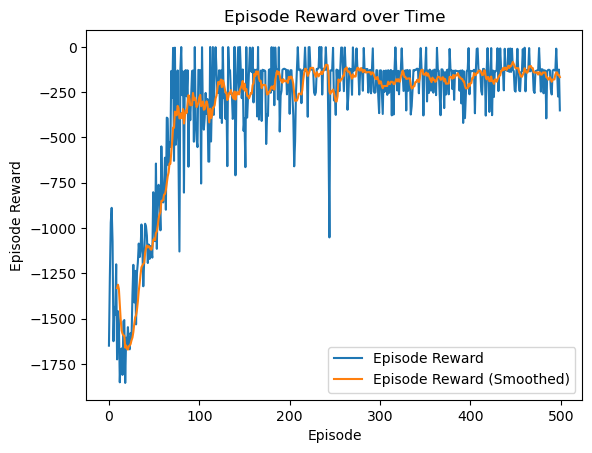

In [7]:
env = NormalizedActions(gym.make('Pendulum-v1'))
Manger = TrainManager(env = env,
                    episode_num = 500,
                    actor_lr = 1e-3,
                    critic_lr = 1e-2,
                    gamma = 0.95,
                    buffer_capacity = 10000,
                    replay_start_size = 1000,
                    actor_update_frequent = 2,
                    target_update_tau = 1e-3,
                    alpha_lr = 1e-3,
                    batch_size = 64,
                    seed = 0,
                    my_device = "cpu"
                    )
Manger.train()
Manger.plotting()